In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries are working!")

All libraries are working!


In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [12]:
df = df.dropna(subset=["TotalCharges"])

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [14]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


In [15]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [16]:
df = df.drop("customerID", axis=1)

In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [18]:
df.select_dtypes(include="object").columns

C:\Users\Zoya Ar\AppData\Local\Temp\ipykernel_1604\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [19]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [20]:
df.shape

(7032, 31)

In [21]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [23]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (5625, 30)
Scaled testing data shape: (1407, 30)


In [28]:
churn_counts = df["Churn"].value_counts()

print("Stayed:", churn_counts[0])
print("Churned:", churn_counts[1])

Stayed: 5163
Churned: 1869


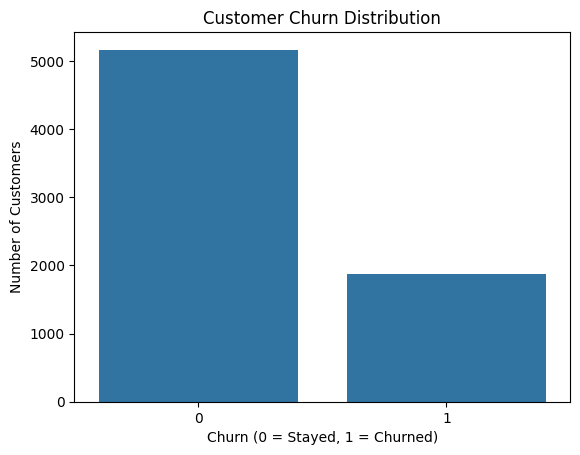

In [29]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

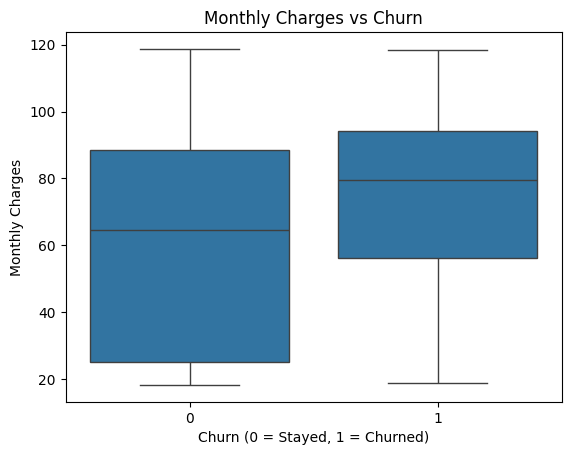

In [30]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Charges")
plt.show()

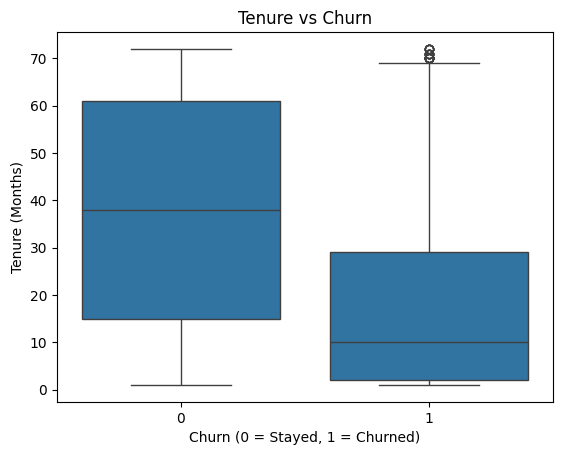

In [31]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Tenure (Months)")
plt.show()

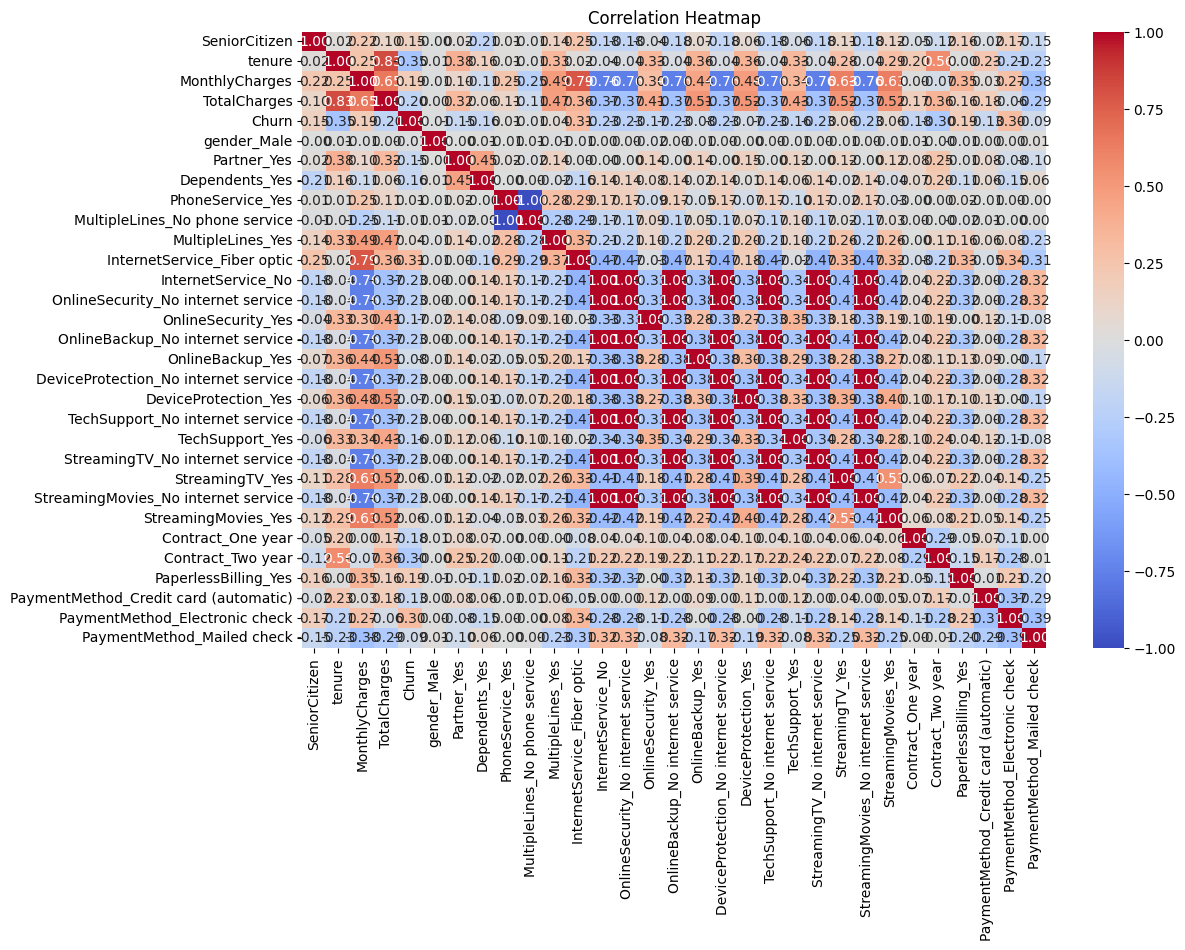

In [32]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [33]:
df["AverageMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, np.nan)

df["AverageMonthlySpend"] = df["AverageMonthlySpend"].fillna(
    df["MonthlyCharges"]
)

df[["tenure", "MonthlyCharges", "TotalCharges", "AverageMonthlySpend"]].head()

,tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [34]:
df["LongTermContract"] = (
    df["Contract_One year"] | df["Contract_Two year"]
).astype(int)

df[["Contract_One year", "Contract_Two year", "LongTermContract"]].head()


,Contract_One year,Contract_Two year,LongTermContract
0,0,0,0
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [35]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 32)
Target: (7032,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 32)
Testing data: (1407, 32)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (5625, 32)
Scaled testing data: (1407, 32)


In [38]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Logistic Regression Results
Accuracy : 0.805
Precision: 0.651
Recall   : 0.578
F1 Score : 0.612


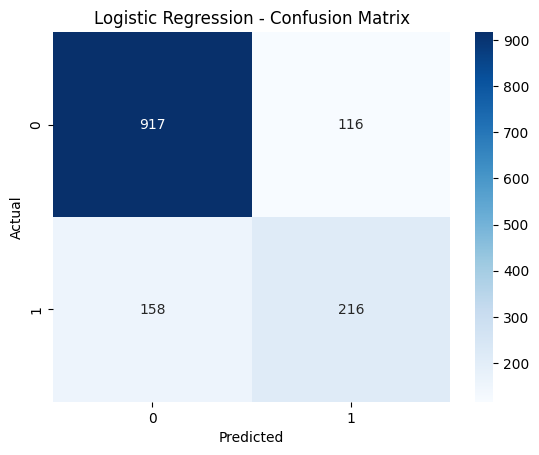

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [42]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("Accuracy :", round(accuracy_tree, 3))
print("Precision:", round(precision_tree, 3))
print("Recall   :", round(recall_tree, 3))
print("F1 Score :", round(f1_tree, 3))

Decision Tree Results
Accuracy : 0.782
Precision: 0.58
Recall   : 0.647
F1 Score : 0.612


In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [44]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", round(accuracy_rf, 3))
print("Precision:", round(precision_rf, 3))
print("Recall   :", round(recall_rf, 3))
print("F1 Score :", round(f1_rf, 3))

Random Forest Results
Accuracy : 0.793
Precision: 0.64
Recall   : 0.508
F1 Score : 0.566


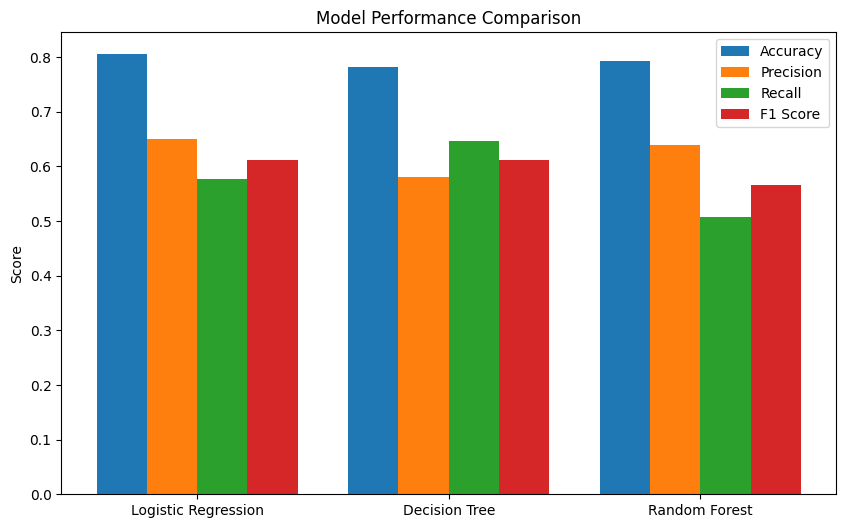

In [45]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracy_scores = [accuracy, accuracy_tree, accuracy_rf]
precision_scores = [precision, precision_tree, precision_rf]
recall_scores = [recall, recall_tree, recall_rf]
f1_scores = [f1, f1_tree, f1_rf]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 0.3, accuracy_scores, width, label="Accuracy")
plt.bar(x - 0.1, precision_scores, width, label="Precision")
plt.bar(x + 0.1, recall_scores, width, label="Recall")
plt.bar(x + 0.3, f1_scores, width, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()


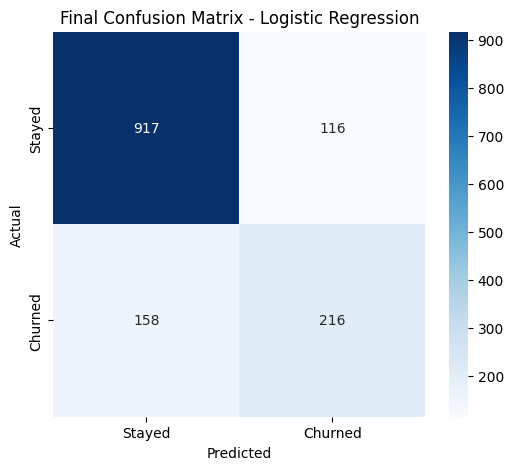

In [46]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Final Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Conclusion

In this project, a Customer Churn Prediction System was developed using a telecom customer dataset. The data was cleaned, categorical variables were converted into numerical form, and irrelevant features such as Customer ID were removed.

Exploratory Data Analysis was performed to understand customer churn patterns, including churn distribution, monthly charges, tenure, and feature correlations. Feature engineering was also applied by creating Average Monthly Spend and a Long-Term Contract feature.

Three machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among the three models, Logistic Regression achieved the highest overall accuracy of **80.5%** and the highest F1 Score of **61.2%**. The Decision Tree achieved the highest Recall of **64.7%**, meaning it identified a larger proportion of customers who actually churned.

Based on the overall performance, **Logistic Regression was selected as the best-performing model for this dataset**.

The system can help companies identify customers who may be at risk of leaving and can support customer-retention strategies by allowing businesses to focus their efforts on higher-risk customers.